## 1. Imports and getting data

In [1]:
import pandas as pd
import sqlite3

In [2]:
db = sqlite3.connect("../data/checking-logs.sqlite")
commits = pd.read_sql("SELECT timestamp AS date FROM checker WHERE uid LIKE 'user_%'", db, parse_dates="date")
commits['date'].dtype

dtype('<M8[ns]')

## 2. Prepocessing

In [3]:

bins = [0, 4, 7, 11, 17, 20, 24]
labels = ["night", "early morning", "morning", "afternoon", "early evening", "evening"]

commits["daytime"] = pd.cut(
    commits["date"].dt.hour,
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)
commits['date'] = commits['date'].dt.date
commits

,date,daytime
0,2020-04-17,early morning
1,2020-04-17,early morning
2,2020-04-17,early morning
3,2020-04-17,early morning
4,2020-04-17,early morning
...,...,...
3202,2020-05-21,evening
3203,2020-05-21,evening
3204,2020-05-21,evening
3205,2020-05-21,evening


In [4]:
counted = pd.crosstab(commits['date'], commits['daytime'])
counted.head()

daytime,night,early morning,morning,afternoon,early evening,evening
date,,,,,,
2020-04-17,0,13,0,10,0,0
2020-04-18,0,0,1,33,21,14
2020-04-19,2,2,9,9,3,8
2020-04-20,0,0,0,12,13,0
2020-04-21,0,0,0,0,17,8


## 3. Creating graph

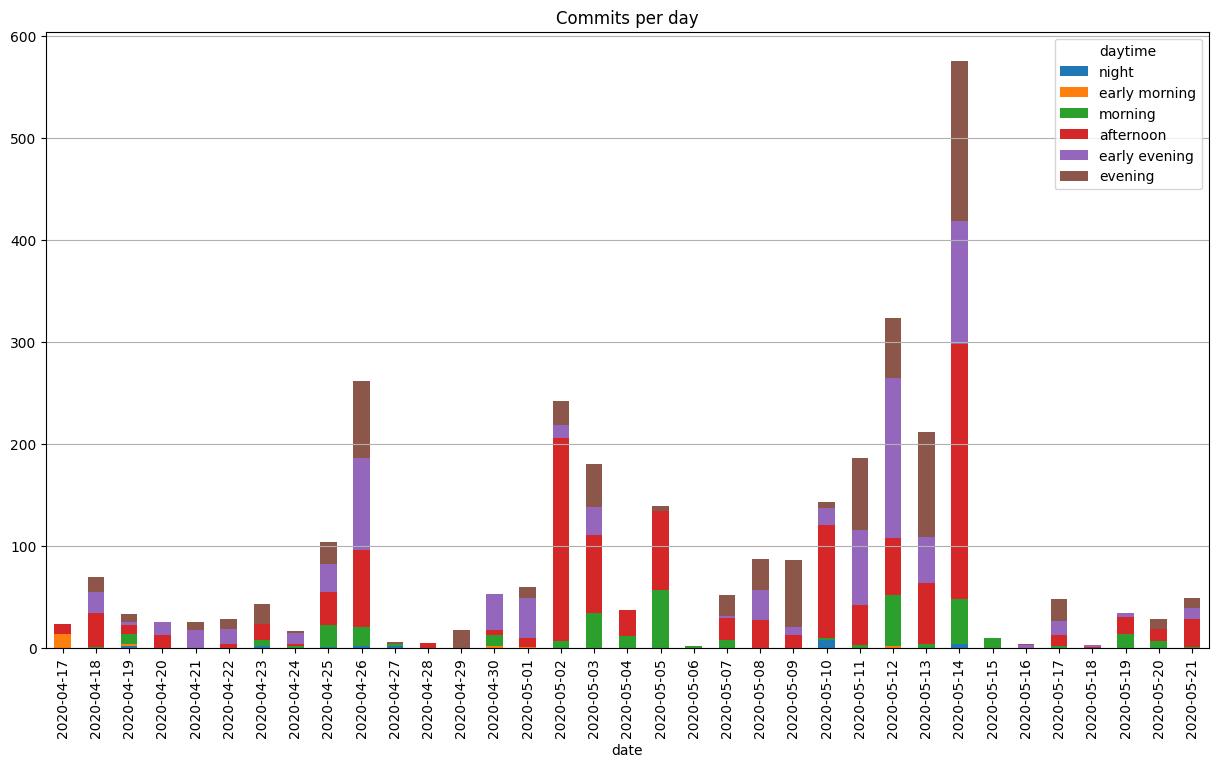

In [5]:
gr = counted.plot(
    kind='bar',
    stacked=True,
    figsize=(15,8),
    rot=90,
    title='Commits per day',
    grid= True
)
gr.xaxis.grid(False)

## 4. Question
- When do our users usually commit to the labs: in the night, morning, afternoon, or evening?  
    - *<u>evening</u> and <u>afternoon</u>*
- Which day has:  
    the most number of commits? And at the same time, is the number of commits higher in the evening than in the afternoon?  
    - *<u>2020-05-12</u>*  

## 5. Closing connection

In [6]:
db.close()